# Feature Extraction Methods Retrieval Performance Analysis

## Confusion Matrix in Day and Night

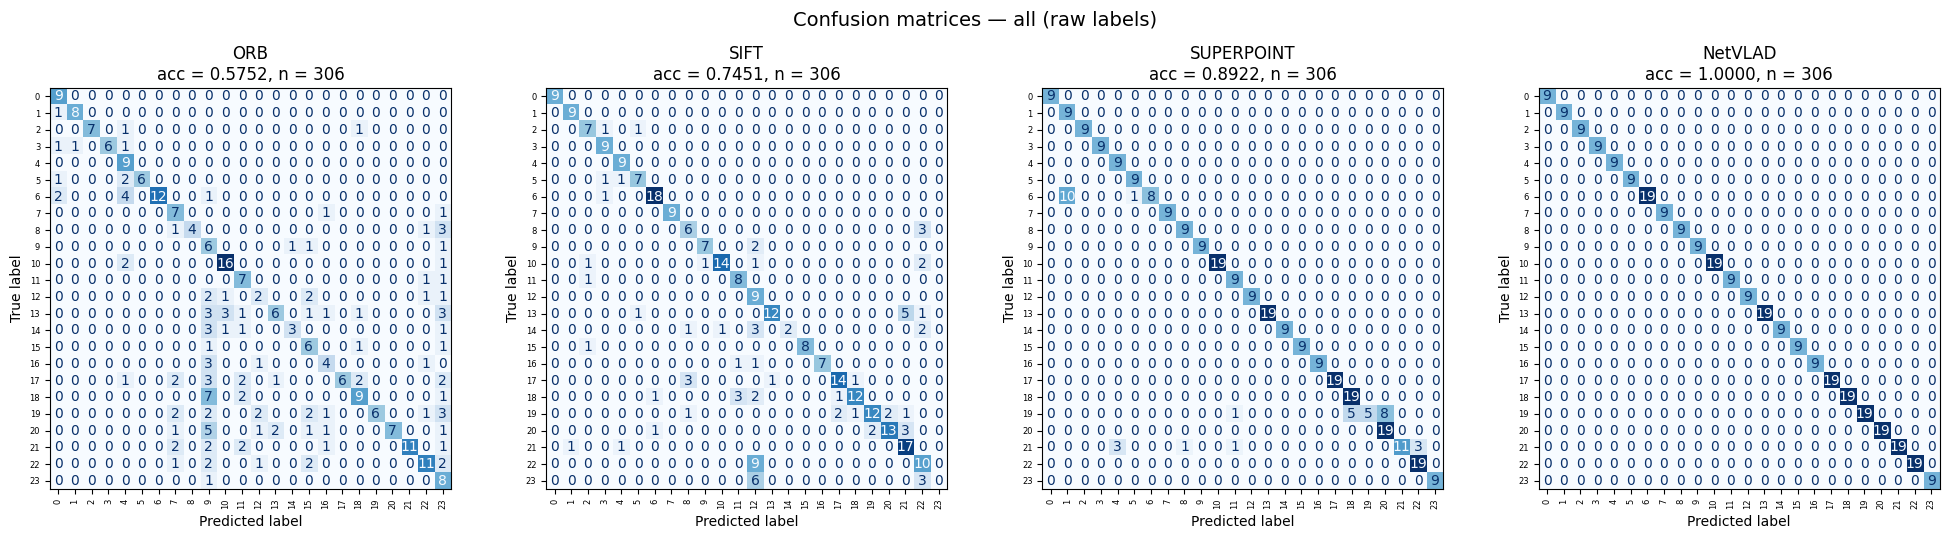

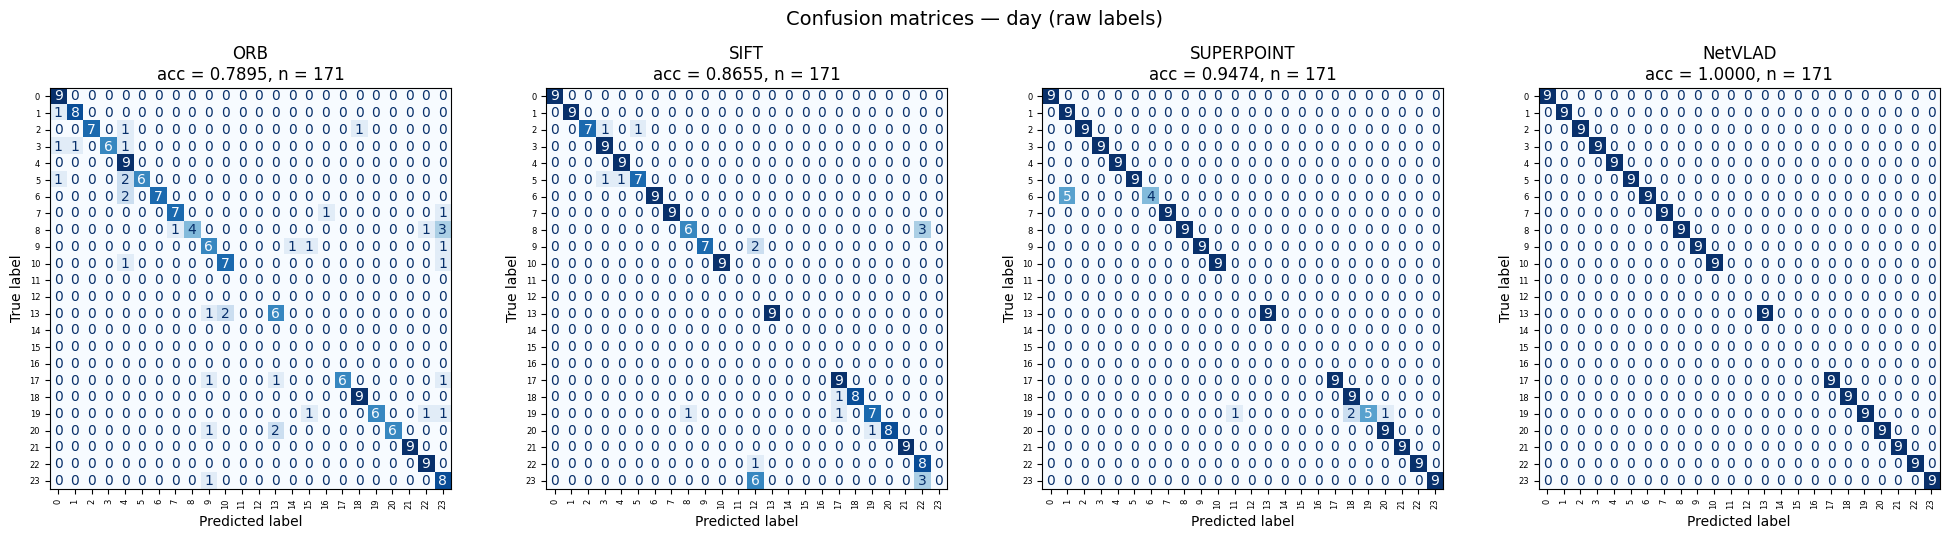

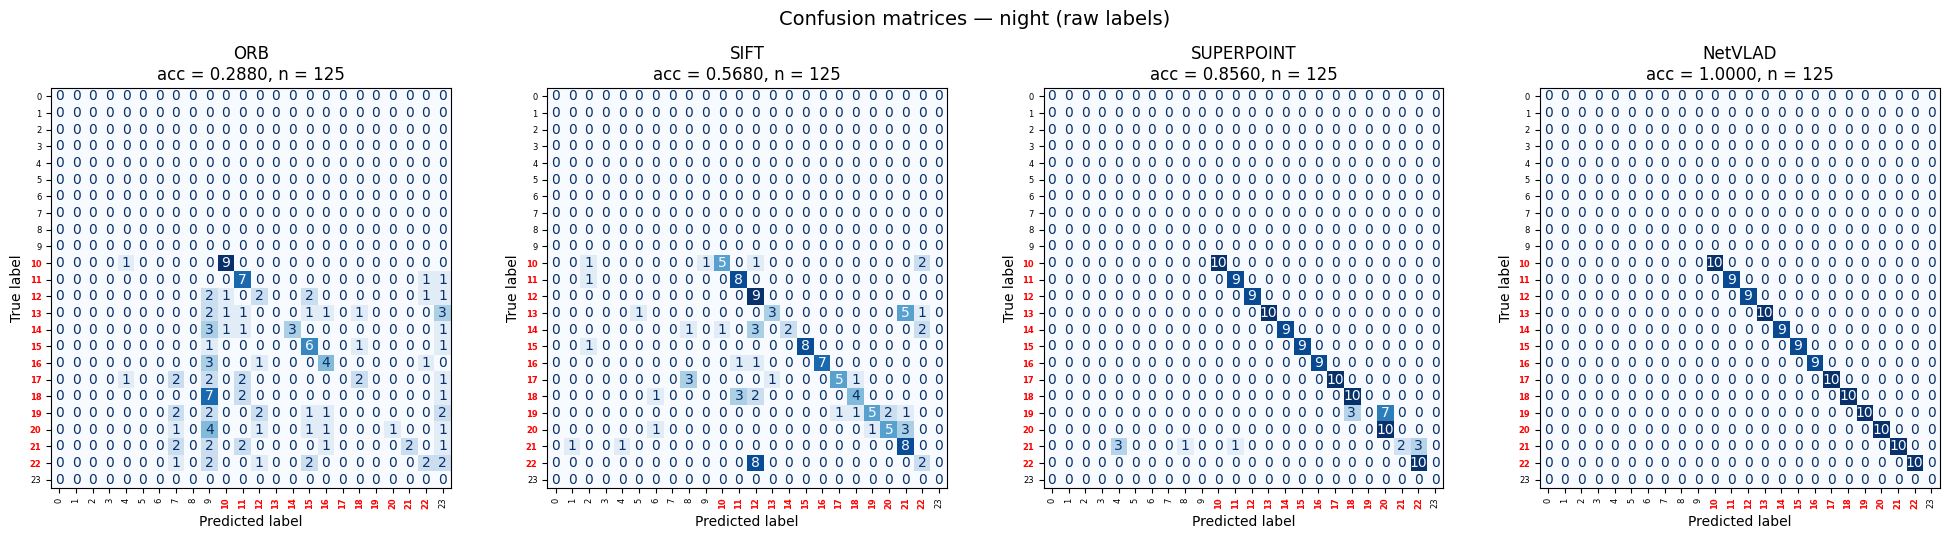

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

RESULTS_DIR = Path('results')

ALGORITHMS = {
    'ORB':        RESULTS_DIR / 'match_details_ref_1_top_1.csv',
    'SIFT':       RESULTS_DIR / 'match_details_SIFT__ref_1_top_1.csv',
    'SUPERPOINT': RESULTS_DIR / 'match_details_SUPERPOINT__ref_1_top_1.csv',
    'NetVLAD':    RESULTS_DIR / 'match_details_NetVLAD__ref_1_top_1.csv',
}

ACTUAL_COL = 'true_place'
PRED_COL   = 'predicted_place'
LIGHT_COL  = 'light'

SPLITS = ('all', 'day', 'night')


def split_by_light(df: pd.DataFrame) -> dict:
    light = df[LIGHT_COL].astype(str)
    return {
        'all':   df,
        'day':   df[light.str.contains('day',   case=False, na=False)],
        'night': df[light.str.contains('night', case=False, na=False)],
    }


def highlight_night_labels(ax, all_labels, night_labels):
    """Color the tick labels red+bold for places that have night queries."""
    night_set = set(night_labels)
    for i, lbl in enumerate(all_labels):
        if lbl in night_set:
            ax.get_xticklabels()[i].set_color('red')
            ax.get_xticklabels()[i].set_fontweight('bold')
            ax.get_yticklabels()[i].set_color('red')
            ax.get_yticklabels()[i].set_fontweight('bold')


# Raw CSVs, no label refinement.
dfs_raw = {algo: pd.read_csv(path) for algo, path in ALGORITHMS.items()}

# Common label set across all algorithms so subplots are aligned.
all_labels = sorted(set().union(*[set(df[ACTUAL_COL]) | set(df[PRED_COL]) for df in dfs_raw.values()]))

# Place ids that have at least one night query (used to highlight tick labels in the night figure).
night_true_labels = set().union(*[set(split_by_light(df)['night'][ACTUAL_COL].unique()) for df in dfs_raw.values()])

for split in SPLITS:
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(dfs_raw),
        figsize=(5 * len(dfs_raw), 5),
        squeeze=False,
    )
    fig.suptitle(f'Confusion matrices \u2014 {split} (raw labels)', fontsize=14, y=1.02)
    for col, (algo, df) in enumerate(dfs_raw.items()):
        sub = split_by_light(df)[split]
        ax = axes[0, col]
        if sub.empty:
            ax.set_axis_off()
            ax.set_title(f'{algo} (empty)')
            continue
        cm = confusion_matrix(sub[ACTUAL_COL], sub[PRED_COL], labels=all_labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_labels)
        disp.plot(cmap='Blues', ax=ax, colorbar=False, values_format='d')
        acc = accuracy_score(sub[ACTUAL_COL], sub[PRED_COL])
        ax.set_title(f'{algo}\nacc = {acc:.4f}, n = {len(sub)}')
        ax.tick_params(axis='x', labelrotation=90, labelsize=6)
        ax.tick_params(axis='y', labelsize=6)
        if split == 'night':
            highlight_night_labels(ax, all_labels, night_true_labels)
    plt.tight_layout()
    plt.show()

## Accuracy in Day and Night

In [3]:
# Per-algorithm, per-split accuracy table (raw labels).
rows = []
for algo, df in dfs_raw.items():
    splits = split_by_light(df)
    rows.append({
        'algorithm': algo,
        **{s: accuracy_score(splits[s][ACTUAL_COL], splits[s][PRED_COL]) if len(splits[s]) else float('nan') for s in SPLITS},
        **{f'n_{s}': len(splits[s]) for s in SPLITS},
    })

acc_df_raw = pd.DataFrame(rows).set_index('algorithm')
display(acc_df_raw.style.format({s: '{:.4f}' for s in SPLITS}))

,all,day,night,n_all,n_day,n_night
algorithm,,,,,,
ORB,0.5752,0.7895,0.2880,306,171,125
SIFT,0.7451,0.8655,0.5680,306,171,125
SUPERPOINT,0.8922,0.9474,0.8560,306,171,125
NetVLAD,1.0000,1.0000,1.0000,306,171,125


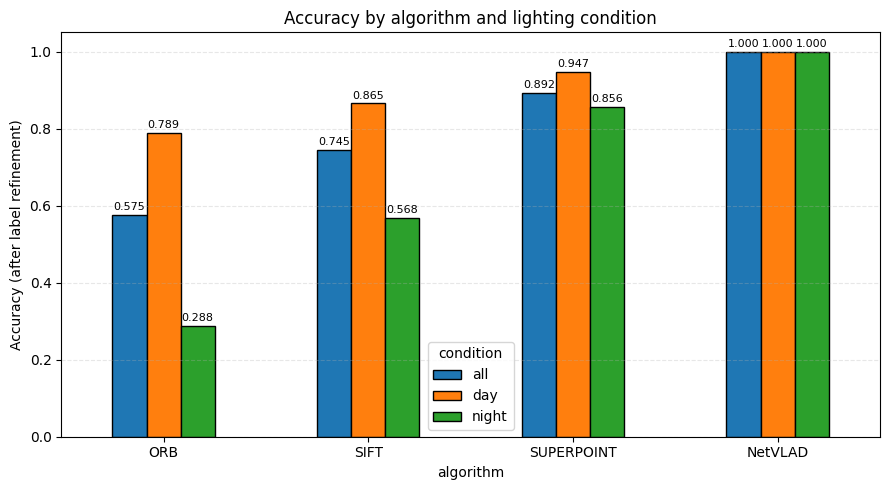

In [4]:
ax = acc_df_raw[list(SPLITS)].plot.bar(figsize=(9, 5), edgecolor='black')
ax.set_ylabel('Accuracy (after label refinement)')
ax.set_ylim(0, 1.05)
ax.set_title('Accuracy by algorithm and lighting condition')
ax.legend(title='condition')
ax.grid(axis='y', linestyle='--', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Refined Label (Only for provided dataset)

In [17]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

RESULTS_DIR = Path('results')

# Algorithms to compare and their match_details CSV paths.
ALGORITHMS = {
    'ORB':        RESULTS_DIR / 'match_details_ref_1_top_1.csv',
    'SIFT':       RESULTS_DIR / 'match_details_SIFT__ref_1_top_1.csv',
    'SUPERPOINT': RESULTS_DIR / 'match_details_SUPERPOINT__ref_1_top_1.csv',
    'NetVLAD':    RESULTS_DIR / 'match_details_NetVLAD__ref_1_top_1.csv',
}

# 19-20, and 21-22 are the same place with different directinons 
# the camera faces roted 90 degrees, so it was considered as different place
# because the content overlap is less than 50%,
# however, powerful algorithms can match them correctly,
# so a refined label is provided for fair evaluation.
LABEL_ALIASES = {20: 19, 22: 21}

ACTUAL_COL = 'true_place'
PRED_COL   = 'predicted_place'
LIGHT_COL  = 'light'


def canonicalize(series: pd.Series) -> pd.Series:
    return series.map(lambda p: LABEL_ALIASES.get(p, p))


def load_refined(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df[ACTUAL_COL] = canonicalize(df[ACTUAL_COL])
    df[PRED_COL]   = canonicalize(df[PRED_COL])
    df['correct'] = df[ACTUAL_COL] == df[PRED_COL]
    return df


def split_by_light(df: pd.DataFrame) -> dict:
    light = df[LIGHT_COL].astype(str)
    return {
        'all':   df,
        'day':   df[light.str.contains('day',   case=False, na=False)],
        'night': df[light.str.contains('night', case=False, na=False)],
    }


dfs = {algo: load_refined(p) for algo, p in ALGORITHMS.items()}

print("=== Refined Labels ===")
# list refined correct counts
for algo, df in dfs.items():
    print(f'{algo:>10}: {len(df):4d} rows, {int(df["correct"].sum()):4d} correct after refinement')

print("\n=== Previous Labels ===")
# list previous correct counts
for algo, df in dfs_raw.items():
    print(f'{algo:>10}: {len(df):4d} rows, {int(df["correct"].sum()):4d} correct after refinement')

=== Refined Labels ===
       ORB:  306 rows,  176 correct after refinement
      SIFT:  306 rows,  232 correct after refinement
SUPERPOINT:  306 rows,  284 correct after refinement
   NetVLAD:  306 rows,  306 correct after refinement

=== Previous Labels ===
       ORB:  306 rows,  176 correct after refinement
      SIFT:  306 rows,  228 correct after refinement
SUPERPOINT:  306 rows,  273 correct after refinement
   NetVLAD:  306 rows,  306 correct after refinement


In [11]:
SPLITS = ('all', 'day', 'night')

# Per-algorithm, per-split accuracy table.
rows = []
for algo, df in dfs.items():
    splits = split_by_light(df)
    rows.append({
        'algorithm': algo,
        **{s: accuracy_score(splits[s][ACTUAL_COL], splits[s][PRED_COL]) if len(splits[s]) else float('nan') for s in SPLITS},
        **{f'n_{s}': len(splits[s]) for s in SPLITS},
    })

acc_df = pd.DataFrame(rows).set_index('algorithm')
display(acc_df.style.format({s: '{:.4f}' for s in SPLITS}))

,all,day,night,n_all,n_day,n_night
algorithm,,,,,,
ORB,0.5752,0.7895,0.2880,306,171,125
SIFT,0.7582,0.8713,0.5920,306,171,125
SUPERPOINT,0.9281,0.9532,0.9360,306,171,125
NetVLAD,1.0000,1.0000,1.0000,306,171,125


### Confusion matrices (refined)

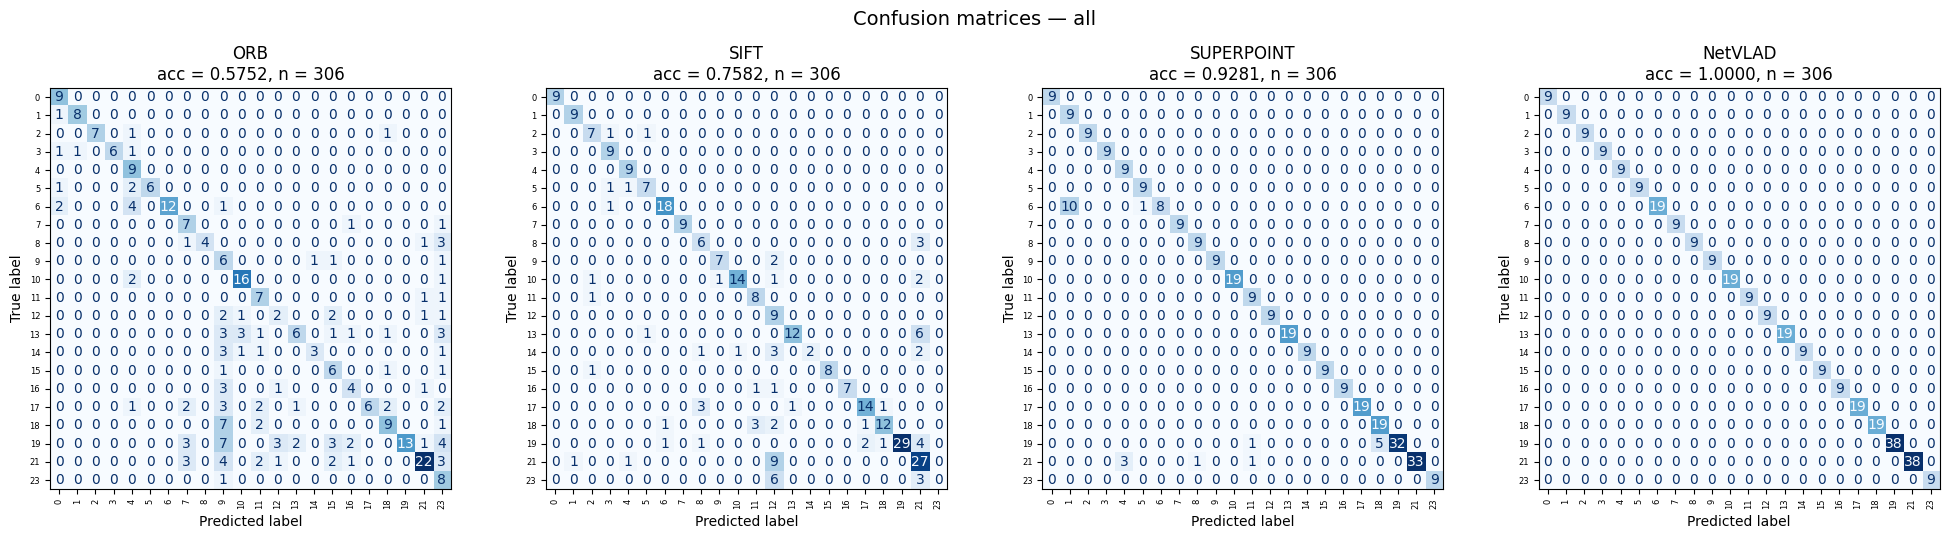

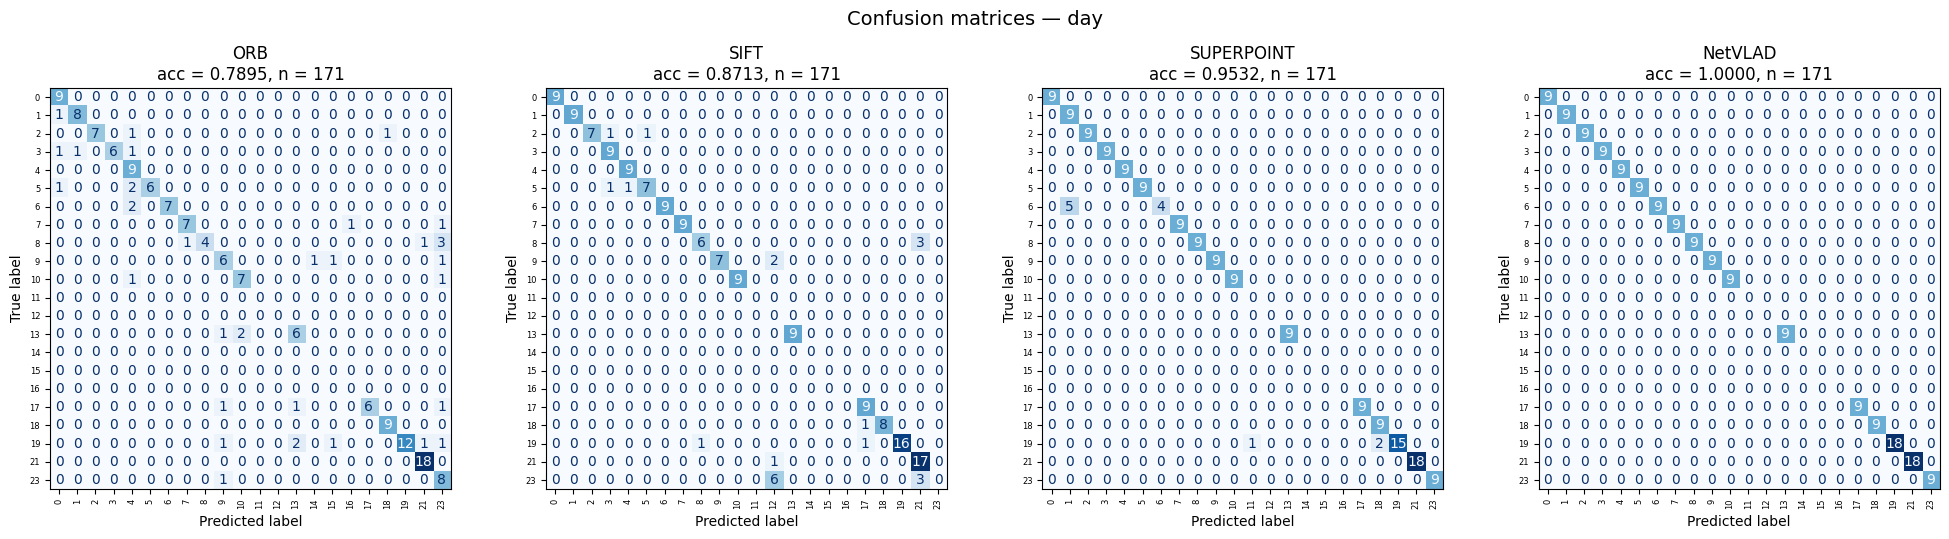

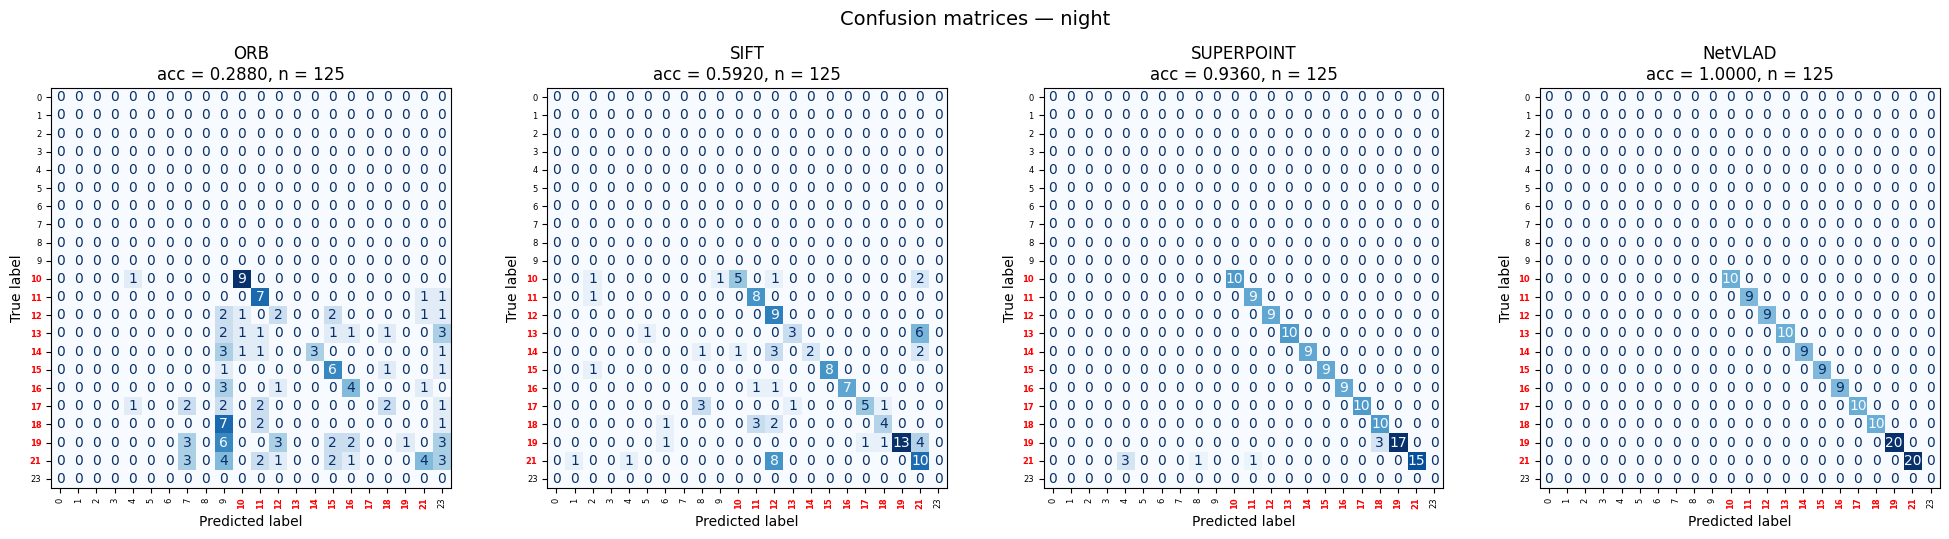

In [12]:
# One figure per split (all / day / night). Each figure: 1 row, one column per algorithm.
all_labels = sorted(set().union(*[set(df[ACTUAL_COL]) | set(df[PRED_COL]) for df in dfs.values()]))

# Place ids that have at least one night query, in the refined label space.
night_true_labels = set().union(*[set(split_by_light(df)['night'][ACTUAL_COL].unique()) for df in dfs.values()])


def highlight_night_labels(ax, labels, night_labels):
    night_set = set(night_labels)
    for i, lbl in enumerate(labels):
        if lbl in night_set:
            ax.get_xticklabels()[i].set_color('red')
            ax.get_xticklabels()[i].set_fontweight('bold')
            ax.get_yticklabels()[i].set_color('red')
            ax.get_yticklabels()[i].set_fontweight('bold')


for split in SPLITS:
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(dfs),
        figsize=(5 * len(dfs), 5),
        squeeze=False,
    )
    fig.suptitle(f'Confusion matrices \u2014 {split}', fontsize=14, y=1.02)
    for col, (algo, df) in enumerate(dfs.items()):
        sub = split_by_light(df)[split]
        ax = axes[0, col]
        if sub.empty:
            ax.set_axis_off()
            ax.set_title(f'{algo} (empty)')
            continue
        cm = confusion_matrix(sub[ACTUAL_COL], sub[PRED_COL], labels=all_labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_labels)
        disp.plot(cmap='Blues', ax=ax, colorbar=False, values_format='d')
        acc = accuracy_score(sub[ACTUAL_COL], sub[PRED_COL])
        ax.set_title(f'{algo}\nacc = {acc:.4f}, n = {len(sub)}')
        ax.tick_params(axis='x', labelrotation=90, labelsize=6)
        ax.tick_params(axis='y', labelsize=6)
        if split == 'night':
            highlight_night_labels(ax, all_labels, night_true_labels)
    plt.tight_layout()
    plt.show()

### Algorithm comparison (refined)

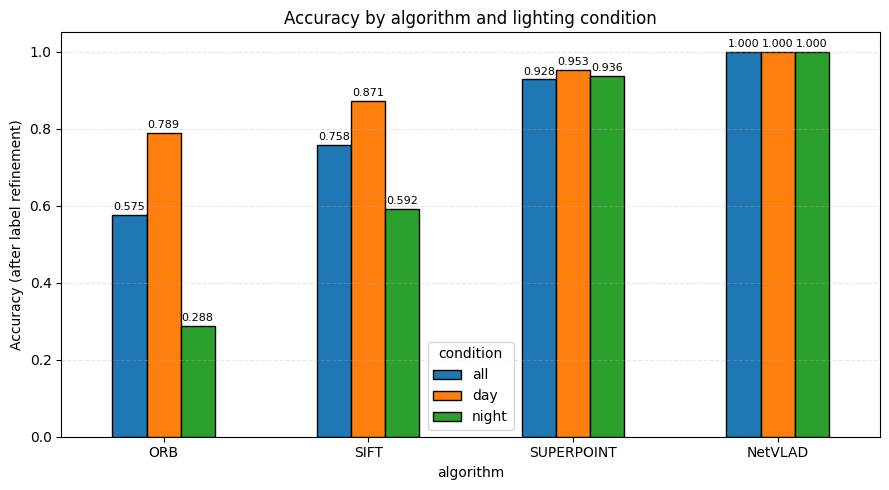

In [13]:
ax = acc_df[list(SPLITS)].plot.bar(figsize=(9, 5), edgecolor='black')
ax.set_ylabel('Accuracy (after label refinement)')
ax.set_ylim(0, 1.05)
ax.set_title('Accuracy by algorithm and lighting condition')
ax.legend(title='condition')
ax.grid(axis='y', linestyle='--', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()